So far:
- we trained using all data at once
- this works only for tiny examples

Real datasets:
- thousands or millions of samples
- cannot fit in memory or GPU at once

So we batch.

### What is batching?

Instead of:
- using all data at once

We:
- split data into small chunks (batches)
- train one batch at a time

Example:
- dataset = 1,000 samples
- batch size = 32
- model updates ~32 samples at once

### Why batching is necessary

- fits in memory
- faster on GPU
- smoother learning
- allows shuffling

### Dataset

A Dataset answers two questions:
- how many samples are there?
- how to get one sample?

We’ll use the California Housing dataset from scikit-learn.

Task:

> Predict house price from features

### Code

#### Step 1: Load the dataset

In [57]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

X = data.data       #features
y = data.target     #house prices

#### Step 2: Convert to PyTorch tensors

In [58]:
import torch

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

Why `.view(-1, 1)`?
- neural networks expect 2D targets

#### Step 3: Train / validation split

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

#### Step 4: Wrap in Dataset + DataLoader

In [60]:
from torch.utils.data import Dataset, DataLoader

class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
        # if X has 10,000 rows
        # PyTorch now knows dataset size = 10,000
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    # "Give me one data point at position index"
    # Example:
        # idx = 5
        # returns (X[5], y[5])
    # Runs for each row in the batch

In [61]:
train_ds = HousingDataset(X_train, y_train)
test_ds = HousingDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)
# - take train_ds
# - give me 64 rows at a time
# - shuffle order every epoch

#### Step 5: Simple real model

In [62]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(X.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

`nn.Sequential`

Means:

“Run layers one after another, in order”

Like a pipeline.

`nn.Linear(X.shape[1], 64)`

This means:
- input size = number of features
- output size = 64 numbers

So:
- model looks at all input columns
- converts them into 64 learned values

This is where learning starts.

`nn.ReLU()`

This just:
- removes negative values
- adds non-linearity

Without this:
- model is too simple
- cannot learn real patterns

`nn.Linear(64, 1)`

This means:
- take those 64 values
- combine them into one final number

That number = predicted house price.

#### Step 6: Train on real data

In [ ]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []

for epoch in range(5):
    for xb, yb in train_loader:     #xb = X batch, yb = y batch
        preds = model(xb)
        loss = loss_fn(preds, yb)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        train_losses.append(loss.item())        
        print(f"Epoch: {epoch} | Loss: {loss.item():.4f}")

Epoch: 0 | Loss: 45991.5469
Epoch: 0 | Loss: 55888.1445
Epoch: 0 | Loss: 35322.2500
Epoch: 0 | Loss: 32674.2324
Epoch: 0 | Loss: 40226.1797
Epoch: 0 | Loss: 16135.5527
Epoch: 0 | Loss: 26332.7266
Epoch: 0 | Loss: 12800.2842
Epoch: 0 | Loss: 6161.4546
Epoch: 0 | Loss: 7009.4355
Epoch: 0 | Loss: 3038.2734
Epoch: 0 | Loss: 3983.6289
Epoch: 0 | Loss: 1371.5952
Epoch: 0 | Loss: 458.5484
Epoch: 0 | Loss: 216.5444
Epoch: 0 | Loss: 54.7639
Epoch: 0 | Loss: 100.8236
Epoch: 0 | Loss: 313.2267
Epoch: 0 | Loss: 602.7479
Epoch: 0 | Loss: 890.3384
Epoch: 0 | Loss: 1668.9198
Epoch: 0 | Loss: 1739.3057
Epoch: 0 | Loss: 1935.8173
Epoch: 0 | Loss: 2356.6821
Epoch: 0 | Loss: 1616.3837
Epoch: 0 | Loss: 2066.2449
Epoch: 0 | Loss: 1522.2131
Epoch: 0 | Loss: 1825.8447
Epoch: 0 | Loss: 2176.2480
Epoch: 0 | Loss: 2609.0552
Epoch: 0 | Loss: 1716.2151
Epoch: 0 | Loss: 1481.5165
Epoch: 0 | Loss: 1218.1534
Epoch: 0 | Loss: 1015.6318
Epoch: 0 | Loss: 852.6332
Epoch: 0 | Loss: 506.9771
Epoch: 0 | Loss: 403.3435
Epoc

### Epoch vs Batch

- Batch → one small chunk of data
- Epoch → one full pass over dataset

If:
- dataset size = 100
- batch size = 25

Then:
- 4 batches = 1 epoch

### Why shuffling matters

Without shuffle:
- model sees data in same order
- learns patterns of order, not data

Shuffle:
- improves generalization
- avoids bias

### Visualization

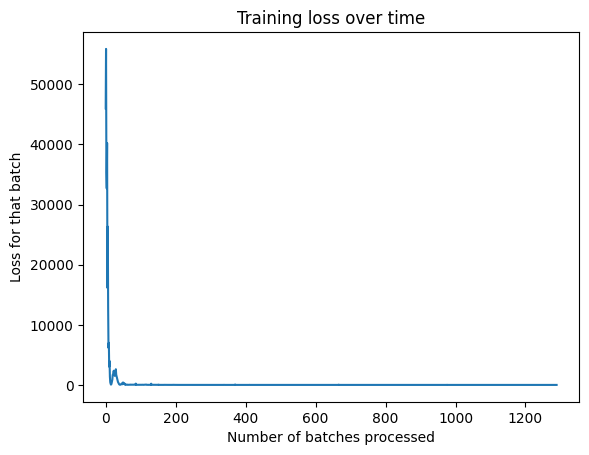

In [64]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Number of batches processed")
plt.ylabel("Loss for that batch")
plt.title("Training loss over time")
plt.show()